<a href="https://colab.research.google.com/github/deadex-ng/arena/blob/main/chapter0_fundamentals/exercises/part3_optimization/gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [113]:
import numpy as np
import matplotlib.pyplot as plt

In [114]:
def quadratic_loss(x,y):
  return x**2 + 10*y**2

In [115]:
def quadratic_grad(x,y):
  dx = 2*x
  dy = 20*y
  return np.array([dx,dy])

In [116]:
def batch_gradient_descent(grad_func, eta, epochs, start_point):
  x, y = start_point
  path = [(x,y)]
  losses = [quadratic_loss(x,y)]

  for _ in range(epochs):
    grad = grad_func(x,y)
    x -= eta * grad[0]
    y -= eta * grad[1]
    path.append((x,y))
    losses.append(quadratic_loss(x,y))
  return np.array(path), losses

In [117]:
def gradient_descent_momentum(grad_func, eta, beta, epochs, start_point):
  x, y = start_point
  v = np.array([0,0])
  path = [(x,y)]
  losses = [quadratic_loss(x,y)]

  for _ in range(epochs):
    grad = grad_func(x,y)
    v = beta * v + (1 - beta) * grad
    x -= eta * v[0]
    y -= eta * v[1]
    path.append((x,y))
    losses.append(quadratic_loss(x,y))

  return np.array(path), losses

In [118]:
def plot_paths(function, paths, labels, title):
    X, Y = np.meshgrid(np.linspace(-2, 2, 400),
                       np.linspace(-2, 2, 400))
    Z = function(X, Y)

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, Z, levels=50, cmap='jet')

    for path, label in zip(paths, labels):
        plt.plot(path[:, 0], path[:, 1], label=label)
        plt.scatter(path[0, 0], path[0, 1], color='green')
        plt.scatter(path[-1, 0], path[-1, 1], color='red')

        # Annotate each point with its coordinates
        # for x, y in path:
        #     plt.annotate(
        #         f"({x:.2f}, {y:.2f})",
        #         (x, y),
        #         textcoords="offset points",
        #         xytext=(5, 5),
        #         fontsize=8
        #     )

    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()

In [119]:
def plot_losses(losses, labels, title):
  plt.figure(figsize=(8,6))
  for loss, label in zip(losses, labels):
    plt.plot(loss, label=label)

  # plt.title(title)
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

In [120]:
eta_bgd = 0.1 #Learing rate for BGD
eta_momentum = 0.1 #Learning rate for momentum
beta = 0.9 #Momentum coefficient
epochs = 50
start_point = (1.5, 1.5)

In [121]:
path_dgd, losses_bdg = batch_gradient_descent(quadratic_grad, eta_bgd, epochs, start_point)
path_momentum, losses_momentum = gradient_descent_momentum(quadratic_grad, eta_momentum, beta, epochs, start_point)

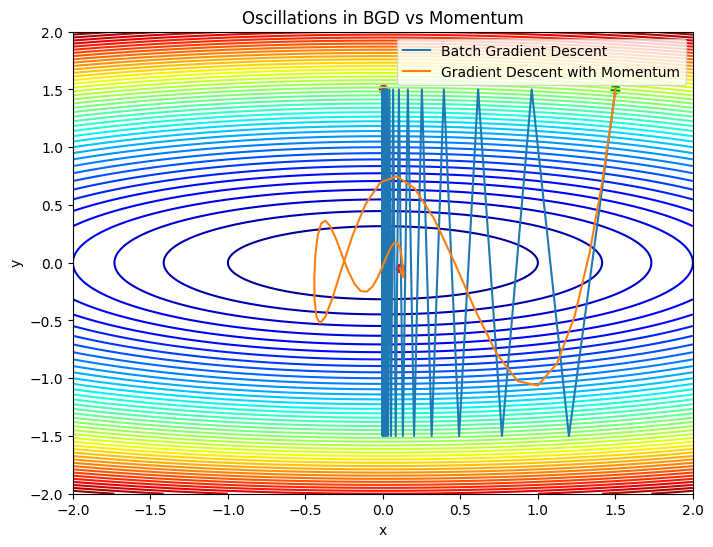

In [122]:
plot_paths(quadratic_loss, [path_dgd, path_momentum], ["Batch Gradient Descent", "Gradient Descent with Momentum"], "Oscillations in BGD vs Momentum")


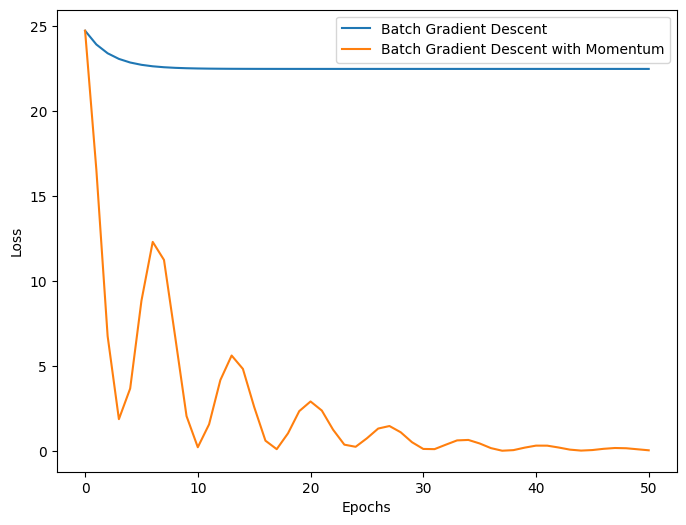

In [123]:
plot_losses([losses_bdg, losses_momentum],["Batch Gradient Descent", "Batch Gradient Descent with Momentum"], "Loss vs Epochs for BGD and Momentum")